# Tier 7 requirements verification

Tier 7 expresses capability requirements as quasi-steady **flight points** whose
Tier 3 operating margins must be non-negative.

`performance/flight_point.py` couples, at one condition:

* hover: thrust per active rotor $= (T/W)\,W/n$;
* airplane mode (tiltrotor cruise): wing lift $= W\cos\gamma$ with $\alpha$ a
  variable, thrust $= D + W\sin\gamma$;
* actuator-disk rotor power, gearbox, McDonald motors at a variable rotor speed,
  battery current and generator torque as variables, the electric power
  fraction $h_e$ split between them, and turboshaft fuel flow.

`requirements/capability.py` provides hover, climb, speed and ceiling
requirements. Sizing rule: sustained requirements are met on turbogenerator power
alone ($h_e = 0$); hover may draw on the battery. `examples/requirements_sizing.py`
resizes the rubber powertrain inside the mass closure at minimum MTOM.

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier7_requirements
```

In [1]:
import ast
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.core.margins import margin_report
from aircraft_closure.performance.flight_point import FlightCondition, acceleration_gravity_m_s2, build_flight_point
from aircraft_closure.requirements.capability import RequirementSet, SpeedRequirement
from examples.aircraft_mass_closure import build_reference_aircraft
from examples.requirements_sizing import solve_requirements_sizing

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


aircraft = build_reference_aircraft(3.23, area_horizontal_tail_m2=2.16, area_vertical_tail_m2=1.92)
aero = SimpleAerodynamics()
mass_kg = 1553.0
weight_N = mass_kg * acceleration_gravity_m_s2


def solve_point(condition, hybridization=None, minimize_fuel=True):
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aero, condition, mass_kg, hybridization)
    if minimize_fuel:
        opti.minimize(point.fuel_flow_kg_s * 100)
    return point, opti.solve(verbose=False)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Flight-point identities

Hover thrust sums to $(T/W)W$ and its shaft power equals the closed-form
actuator-disk value; airplane-mode lift and thrust satisfy the flight-path force
balance; the bus splits motor demand by $h_e$; fuel flow is the turboshaft model
at the generator shaft power.

In [2]:
hover, s = solve_point(FlightCondition(mode="hover", altitude_m=0.0, label="hover"))
rotor_model = aircraft.powertrain.topology.instances["propulsor"].component
expected_W = float(rotor_model.evaluate(0, asb.Atmosphere(altitude=0), thrust_N=weight_N / 4).shaft_power_W)
check("hover: thrust per rotor x 4 = weight", close(float(s.value(4 * hover.thrust_per_rotor_N)), weight_N, rel=1e-9))
check("hover: rotor shaft power = actuator-disk closed form", close(float(s.value(hover.power_shaft_rotor_W)), expected_W, rel=1e-9))
check("hover: motor shaft power = rotor power / gearbox efficiency",
      close(float(s.value(hover.speed_motor_rad_s * hover.torque_motor_Nm)), expected_W / 0.97, rel=1e-9))

climb, s = solve_point(FlightCondition(velocity_m_s=50.0, climb_rate_m_s=5.0, label="climb"), hybridization=0.0)
sin_gamma = 0.1
check("airplane: lift = W cos(gamma)", close(float(s.value(climb.aero.lift_N)), weight_N * np.sqrt(1 - sin_gamma**2), rel=1e-9))
check("airplane: thrust = D + W sin(gamma)",
      close(float(s.value(4 * climb.thrust_per_rotor_N)), float(s.value(climb.aero.drag_N)) + weight_N * sin_gamma, rel=1e-9))
check("airplane: h_e = 0 draws no battery power", abs(float(s.value(climb.power_battery_W))) < 1e-6)

cruise, s = solve_point(FlightCondition(velocity_m_s=60.0, label="cruise"), hybridization=0.4)
demand_W = float(s.value(cruise.power_electric_motors_W))
check("bus: battery supplies h_e of motor demand", close(float(s.value(cruise.power_battery_W)), 0.4 * demand_W, rel=1e-8))
check("bus: generator supplies the rest", close(float(s.value(cruise.generator.power_electric_W)), 0.6 * demand_W, rel=1e-8))
check("margins: every margin is labelled with its point", all(m.label.startswith("cruise: ") for m in cruise.margins))

PASS  hover: thrust per rotor x 4 = weight
PASS  hover: rotor shaft power = actuator-disk closed form
PASS  hover: motor shaft power = rotor power / gearbox efficiency
PASS  airplane: lift = W cos(gamma)
PASS  airplane: thrust = D + W sin(gamma)
PASS  airplane: h_e = 0 draws no battery power
PASS  bus: battery supplies h_e of motor demand
PASS  bus: generator supplies the rest
PASS  margins: every margin is labelled with its point


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


## 2. Power required across the envelope

Hover power rises with density altitude; airplane-mode shaft power follows the
drag-power curve plus the climb term $W\dot h$; the electrical input adds motor and
gearbox losses. These are the curves the requirements sample.

PASS  trend: hover power rises with altitude


PASS  trend: 5 m/s climb adds about W x climb rate / rotor efficiency


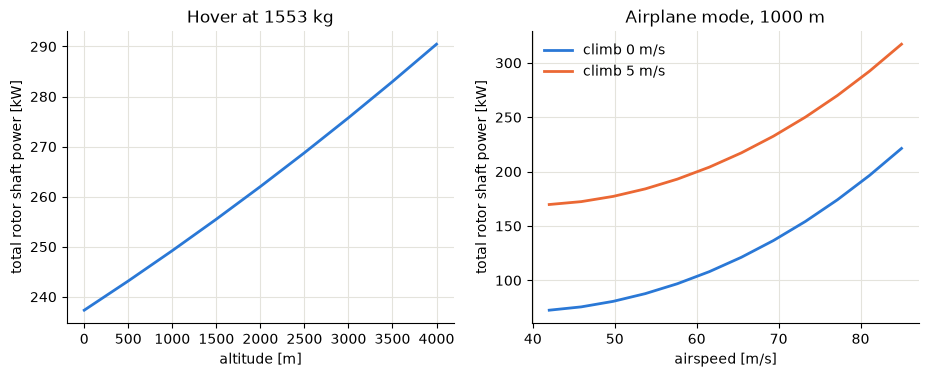

In [3]:
altitudes = np.linspace(0, 4000, 9)
hover_kW = []
for h in altitudes:
    p, s = solve_point(FlightCondition(mode="hover", altitude_m=h, label="hover"))
    hover_kW.append(4 * float(s.value(p.power_shaft_rotor_W)) / 1e3)
check("trend: hover power rises with altitude", np.all(np.diff(hover_kW) > 0))
speeds = np.linspace(42, 85, 12)
curves = {}
for rate, color in ((0.0, blue), (5.0, orange)):
    shaft = []
    for v in speeds:
        p, s = solve_point(FlightCondition(velocity_m_s=v, altitude_m=1000.0, climb_rate_m_s=rate, label="pt"), hybridization=0.0)
        shaft.append(4 * float(s.value(p.power_shaft_rotor_W)) / 1e3)
    curves[rate] = np.array(shaft)
check("trend: 5 m/s climb adds about W x climb rate / rotor efficiency",
      np.all(curves[5.0] - curves[0.0] > weight_N * 5.0 / 1e3 * 0.95))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(altitudes, hover_kW, color=blue, lw=2)
ax1.set(xlabel="altitude [m]", ylabel="total rotor shaft power [kW]", title=f"Hover at {mass_kg:.0f} kg")
for rate, color in ((0.0, blue), (5.0, orange)):
    ax2.plot(speeds, curves[rate], color=color, lw=2, label=f"climb {rate:.0f} m/s")
ax2.set(xlabel="airspeed [m/s]", ylabel="total rotor shaft power [kW]", title="Airplane mode, 1000 m")
ax2.legend(frameon=False)
plt.show()

## 3. Requirements on the fixed Tier 6 aircraft

With the reference ratings (100 kW motors, 400 kW generator, 600 kW turboshaft),
each requirement point is solved with its margins as constraints; feasibility
and the smallest margin per point are reported.

In [4]:
requirements = RequirementSet()
for condition in requirements.flight_conditions():
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aero, condition, mass_kg)
    opti.subject_to([m.value >= 0 for m in point.margins])
    opti.minimize(point.fuel_flow_kg_s * 100)
    s = opti.solve(verbose=False)
    worst = margin_report(point.margins, s.value)[0]
    print(f"{condition.label:<10} shaft/rotor {float(s.value(point.power_shaft_rotor_W)) / 1e3:6.1f} kW, "
          f"h_e {float(s.value(point.hybridization_electric)):.2f}, smallest margin {worst.label} {float(worst.value):+.3f}")
    check(f"fixed aircraft: {condition.label} requirement feasible", float(worst.value) > -1e-6)

hover      shaft/rotor   71.9 kW, h_e 1.00, smallest margin hover: generator max_voltage_V +0.117
PASS  fixed aircraft: hover requirement feasible
climb      shaft/rotor   44.4 kW, h_e 0.00, smallest margin climb: generator max_voltage_V +0.111
PASS  fixed aircraft: climb requirement feasible
max_speed  shaft/rotor   47.5 kW, h_e 0.00, smallest margin max_speed: generator max_voltage_V +0.111
PASS  fixed aircraft: max_speed requirement feasible
ceiling    shaft/rotor   25.0 kW, h_e 0.00, smallest margin ceiling: generator max_voltage_V +0.111
PASS  fixed aircraft: ceiling requirement feasible


## 4. Reference case: sizing the powertrain to the requirements

Minimum MTOM over wing position, motor and generator peak torques, turboshaft
rating, battery discharge power and rotor disk area (bounded at 15 m2), with mass
closure, hover pitch trim and every requirement margin $\ge 0$. Max speed on
turbogenerator power sizes the turboshaft and generator; hover sizes the motor,
gearbox and rotor ratings. Point requirements carry no energy cost, so the
optimizer accepts a high disk loading; Tier 8/9 adds hover energy.

binding: ['hover: gearbox power_input_W', 'hover: motor power_shaft_W', 'hover: propulsor power_shaft_W', 'max_speed: generator power_shaft_W', 'max_speed: turboshaft power_shaft_W']
MTOM 1113.4 kg; motor 73.2 kW, generator 200.3 kW, turboshaft 200.3 kW, battery 243.4 kW, disk 3.77 m2, hover h_e 0.67
PASS  sizing: every requirement margin non-negative
PASS  sizing: max speed sizes the turboshaft
PASS  sizing: hover sizes the motor
PASS  sizing: sustained points draw no battery power
PASS  sizing: turboshaft rated to the generator
PASS  sizing: masses sum to MTOM
PASS  sizing: resized powertrain is lighter than the fixed reference (880 kg)


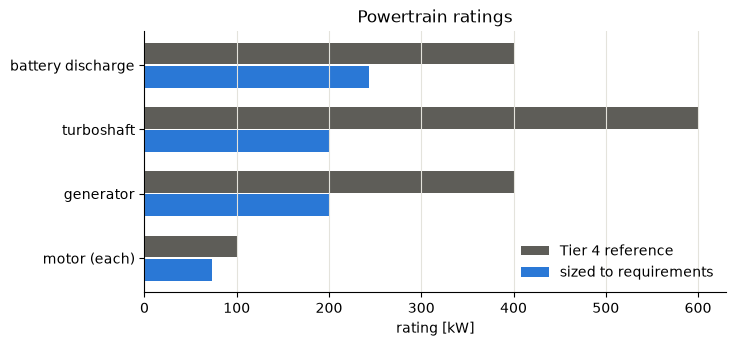

In [5]:
sized = solve_requirements_sizing()
binding = sorted(label for label, m in sized.margins if abs(m) < 1e-6)
print("binding:", binding)
print(f"MTOM {sized.mass_takeoff_kg:.1f} kg; motor {sized.power_rated_motor_W / 1e3:.1f} kW, generator "
      f"{sized.power_rated_generator_W / 1e3:.1f} kW, turboshaft {sized.power_rated_turboshaft_W / 1e3:.1f} kW, "
      f"battery {sized.power_max_discharge_battery_W / 1e3:.1f} kW, disk {sized.area_disk_m2:.2f} m2, hover h_e {sized.hybridization_hover:.2f}")
check("sizing: every requirement margin non-negative", all(m > -1e-6 for _, m in sized.margins))
check("sizing: max speed sizes the turboshaft", "max_speed: turboshaft power_shaft_W" in binding)
check("sizing: hover sizes the motor", "hover: motor power_shaft_W" in binding)
check("sizing: sustained points draw no battery power",
      all(abs(b) < 1e-6 for label, _, b, _ in sized.point_powers_W if label != "hover"))
check("sizing: turboshaft rated to the generator", close(sized.power_rated_turboshaft_W, sized.power_rated_generator_W, rel=1e-6))
check("sizing: masses sum to MTOM", close(sum(m for _, m in sized.component_masses_kg), sized.mass_takeoff_kg, rel=1e-9))
check("sizing: resized powertrain is lighter than the fixed reference (880 kg)",
      dict(sized.component_masses_kg)["powertrain"] < 880.0)

labels = ["motor (each)", "generator", "turboshaft", "battery discharge"]
reference_kW = [100, 400, 600, 400]
sized_kW = [sized.power_rated_motor_W / 1e3, sized.power_rated_generator_W / 1e3,
            sized.power_rated_turboshaft_W / 1e3, sized.power_max_discharge_battery_W / 1e3]
y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(y + 0.18, reference_kW, height=0.34, color=ink_muted, label="Tier 4 reference")
ax.barh(y - 0.18, sized_kW, height=0.34, color=blue, label="sized to requirements")
ax.set_yticks(y, labels)
ax.set(xlabel="rating [kW]", title="Powertrain ratings")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
plt.show()

In [6]:
# Requirement sweep: the speed requirement sets the turbogenerator rating.
speeds_req = [70.0, 80.0, 90.0]
sweep = [solve_requirements_sizing(replace(RequirementSet(), speed=SpeedRequirement(velocity_m_s=v))) for v in speeds_req]
for v, r in zip(speeds_req, sweep):
    print(f"V_max {v:.0f} m/s: turboshaft {r.power_rated_turboshaft_W / 1e3:6.1f} kW, MTOM {r.mass_takeoff_kg:7.1f} kg")
check("sweep: turboshaft rating rises with required speed", np.all(np.diff([r.power_rated_turboshaft_W for r in sweep]) > 0))
check("sweep: MTOM rises with required speed", np.all(np.diff([r.mass_takeoff_kg for r in sweep]) > 0))

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


V_max 70 m/s: turboshaft  140.9 kW, MTOM  1048.2 kg
V_max 80 m/s: turboshaft  200.3 kW, MTOM  1113.4 kg
V_max 90 m/s: turboshaft  279.2 kW, MTOM  1199.7 kg
PASS  sweep: turboshaft rating rises with required speed
PASS  sweep: MTOM rises with required speed


## 5. Boundaries

The flight point is orchestration: it may create Opti variables. The
requirements module only describes conditions, and the lower layers (core,
powertrain, vehicle, aerodynamics, controls) never import performance or
requirements.

In [7]:
package = repo_root / "src/aircraft_closure"
for layer in ("core", "powertrain", "vehicle", "aerodynamics", "controls"):
    for path in sorted((package / layer).rglob("*.py")):
        tree = ast.parse(path.read_text(encoding="utf-8"))
        imports = {n.module or "" for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
        check(f"boundaries: {path.relative_to(package).as_posix()} imports no performance/requirements",
              not any(("performance" in m) or ("requirements" in m) for m in imports))
tree = ast.parse((package / "requirements/capability.py").read_text(encoding="utf-8"))
used = {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
check("boundaries: requirements create no Opti variables", "variable" not in used)

PASS  boundaries: core/__init__.py imports no performance/requirements
PASS  boundaries: core/margins.py imports no performance/requirements
PASS  boundaries: core/ports.py imports no performance/requirements
PASS  boundaries: core/topology.py imports no performance/requirements
PASS  boundaries: powertrain/__init__.py imports no performance/requirements
PASS  boundaries: powertrain/compatibility.py imports no performance/requirements
PASS  boundaries: powertrain/components/__init__.py imports no performance/requirements
PASS  boundaries: powertrain/components/battery.py imports no performance/requirements
PASS  boundaries: powertrain/components/gearbox.py imports no performance/requirements
PASS  boundaries: powertrain/components/generator.py imports no performance/requirements
PASS  boundaries: powertrain/components/motor.py imports no performance/requirements
PASS  boundaries: powertrain/components/propulsor.py imports no performance/requirements
PASS  boundaries: powertrain/compone

## 6. Summary and unit test suite

In [8]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

51 / 51 notebook checks passed


In [9]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 155 tests in 2.042s

OK
